## Import Libraries

In [ ]:
import os
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import friedmanchisquare

## Set Constants

In [ ]:
session, scan, field = 6, 6, 2

sign_constraint = True # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

metric = 'Modularity' # choose the metric: Accuracy, Assortativity, Entropy, Loss, Modularity, SmallWorldness, Validation_Accuracy, Validation_Loss

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name = f'/content/data/simu/{base}'


task1_file_dir = f'{folder_name}/Task1/{metric}_raw.csv'
task2_file_dir = f'{folder_name}/Task2/{metric}_raw.csv'
task3_file_dir = f'{folder_name}/Task3/{metric}_raw.csv'

## Load Dataset

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/ISP

Papers	simu.zip


In [ ]:
!unzip /content/drive/MyDrive/ISP/simu.zip -d /content/data

Archive:  /content/drive/MyDrive/ISP/simu.zip
   creating: /content/data/simu/
   creating: /content/data/simu/5_6_8_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._5_6_8_sttc-precision_sign+  
  inflating: /content/data/simu/.DS_Store  
  inflating: /content/data/__MACOSX/simu/._.DS_Store  
   creating: /content/data/simu/5_6_8_sttc-corr_sign+/
  inflating: /content/data/__MACOSX/simu/._5_6_8_sttc-corr_sign+  
   creating: /content/data/simu/5_3_4_sttc-corr/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-corr  
   creating: /content/data/simu/5_3_4_sttc-corr_sign+/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-corr_sign+  
   creating: /content/data/simu/5_3_4_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-precision_sign+  
   creating: /content/data/simu/6_6_2_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._6_6_2_sttc-precision_sign+  
   creating: /content/data/simu/6_6_2_sttc-precision/
  inflating: /cont

In [ ]:
print(os.listdir("/content/data/simu"))

['5_6_8_sttc-precision', 'rcc.ipynb', '6_6_2_sttc-precision', '5_6_8_sttc-precision_sign+', 'plotting.ipynb', '6_6_2_sttc-corr_sign+', '5_3_4_sttc-precision_sign+', '6_6_2_sttc-corr', '6_6_2_sttc-precision_sign+', '.DS_Store', '5_3_4_sttc-corr_sign+', '5_6_8_sttc-corr', '5_6_8_sttc-corr_sign+', '5_3_4_sttc-corr', '5_3_4_sttc-precision']


## Predefined Functions

In [ ]:
def check_disturbution_difference(df, models):
  same = []
  for i in range(len(models)):
    for j in range (i + 1, len(models)):
      stat, p = mannwhitneyu(df[models[i]], df[models[j]], alternative="two-sided")
      print(f'Model {models[i]} vs Model {models[j]}')
      print(f'stat = {stat}, p = {p}')
      if p > 0.05:
        # print('Same distribution (fail to reject H0)')
        same.append((models[i], models[j]))
      # else:
        # print('Different distribution (reject H0)')
      # print()
  return same

In [ ]:
def calculate_confidence_interval(data, confidence_level=0.95):
    n = len(data)
    acc_task = data.dropna().values
    mean_acc = np.mean(acc_task)
    sem = stats.sem(acc_task)  # standard error of the mean
    ci95 = stats.t.interval(0.95, df=n-1, loc=mean_acc, scale=sem)

    return mean_acc, ci95

In [ ]:
def naive_disturbution_comparision_across_tasks(df1, df2, df3, models, metric_name):
  for model in models:
    plt.figure(figsize=(6,4))

    plt.hist(df1[model], bins=10, alpha=0.5, label="Task 1", density=True)
    plt.hist(df2[model], bins=10, alpha=0.5, label="Task 2", density=True)
    plt.hist(df3[model], bins=10, alpha=0.5, label="Task 3", density=True)

    plt.title(f"{metric_name} Distribution for {model}")
    plt.xlabel(f"{metric_name}")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def task_box_plots(dfs, metric_name):
  task_names = ["Task 1", "Task 2", "Task 3"]

  for i, (df, name) in enumerate(zip(dfs, task_names)):
    task1_long = df.melt(var_name="Model", value_name=metric_name)

    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Model", y=metric_name, data=task1_long)

    plt.xticks(rotation=45)
    plt.title(f"{metric_name} Distributions of Models on {task_names[i]}")
    plt.xlabel("Model Variants")
    plt.ylabel(metric_name)
    plt.tight_layout()
    plt.show()

In [ ]:
def draw_model_disturbutions(df, models, metric_name):
  for model in models:

    plt.figure(figsize=(6,4))

    plt.hist(df[model], bins=10, alpha=0.5, density=True)

    plt.title(f"{metric_name} Distribution for {model}")
    plt.xlabel(metric_name)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Accuracy Analysis

In [ ]:
print(os.listdir(folder_name))

['RCC1', 'Task1.png', 'metrics_SD.csv', 'Task2', 'Task2.png', 'config.txt', 'Task1', '.DS_Store', 'Task3.png', 'Task3', 'RCC3', 'metrics.csv', 'RCC2']


In [ ]:
df1 = pd.read_csv(task1_file_dir)
df2 = pd.read_csv(task2_file_dir)
df3 = pd.read_csv(task3_file_dir)

In [ ]:
df1.drop('simulation', axis=1, inplace=True)
df2.drop('simulation', axis=1, inplace=True)
df3.drop('simulation', axis=1, inplace=True)

In [ ]:
df1.head(20)

,W*D*C,WD*C,WDC,WD*,WD,W,W*D*C*,WD*C*,W*DC*,W!D*C,W!D*C*
0,3.244314,NaN,NaN,NaN,NaN,NaN,0.295529,NaN,0.007013,2.630536,0.134696
1,2.754349,NaN,NaN,NaN,NaN,NaN,0.204871,NaN,0.008006,1.534552,0.191093
2,1.273240,NaN,NaN,NaN,NaN,NaN,0.102535,NaN,0.260990,2.728209,0.243702
3,2.505805,NaN,NaN,NaN,NaN,NaN,0.520070,NaN,0.019629,2.896857,0.317606
4,2.828275,NaN,NaN,NaN,NaN,NaN,0.085946,NaN,0.038245,2.843401,0.069439
5,2.592992,NaN,NaN,NaN,NaN,NaN,0.264639,NaN,0.017254,3.181211,0.617198
6,2.662688,NaN,NaN,NaN,NaN,NaN,0.202868,NaN,0.010013,2.511012,0.328343
7,3.353559,NaN,NaN,NaN,NaN,NaN,0.178919,NaN,0.006290,1.935845,0.039205
8,3.462231,NaN,NaN,NaN,NaN,NaN,0.080969,NaN,0.015491,2.942942,0.172757
9,3.006265,NaN,NaN,NaN,NaN,NaN,0.204372,NaN,0.030392,1.960669,0.159785


In [ ]:
models = df1.columns

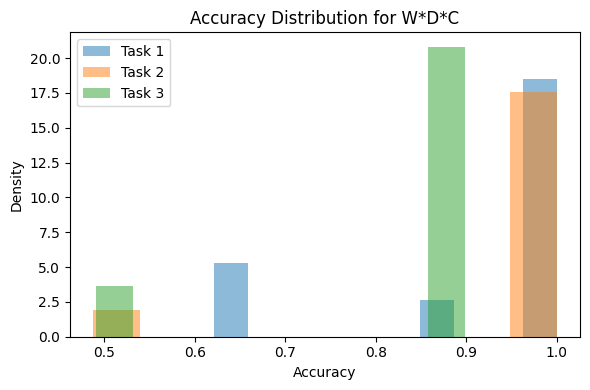

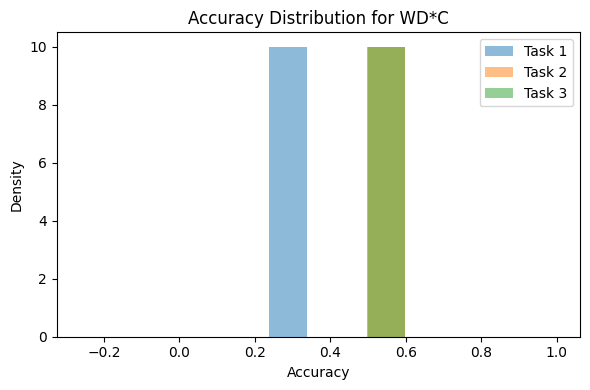

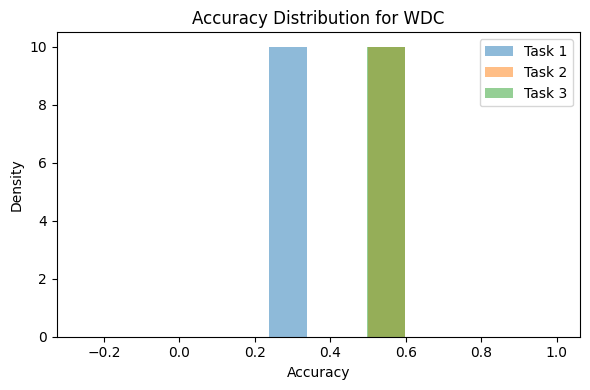

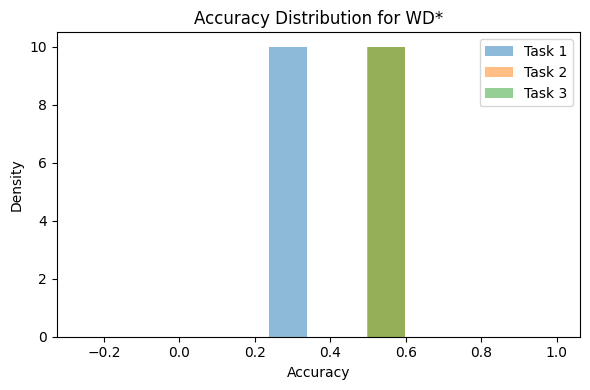

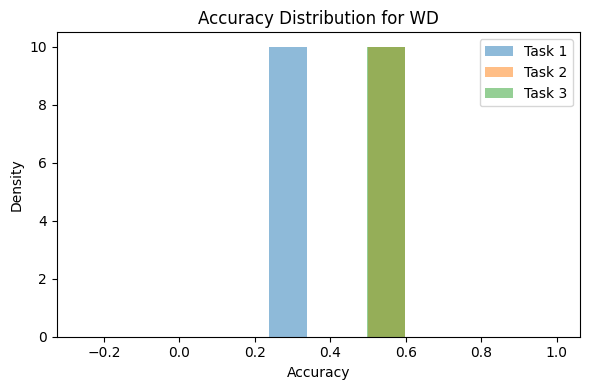

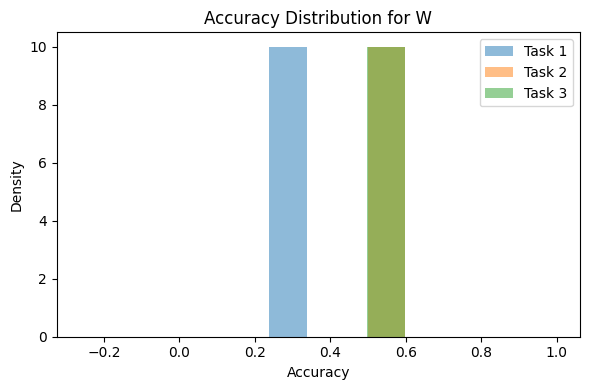

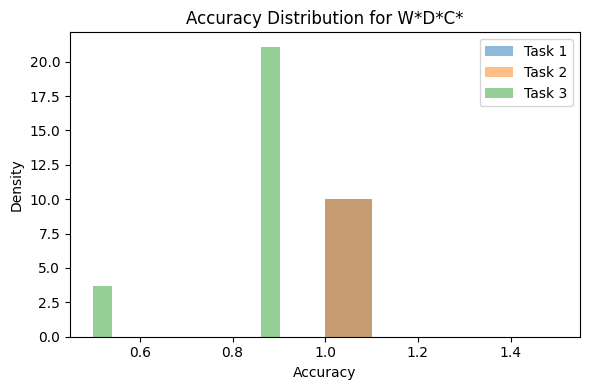

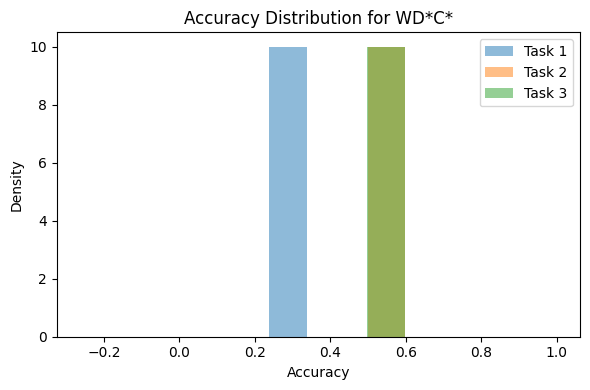

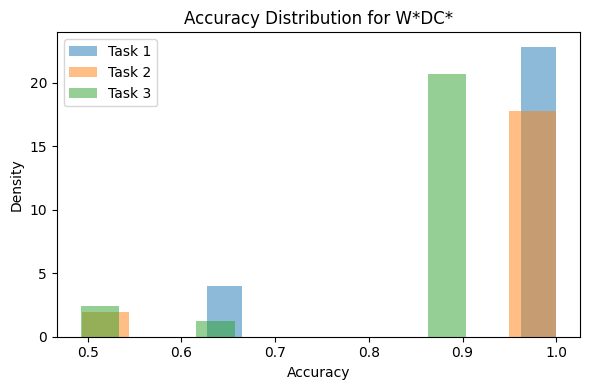

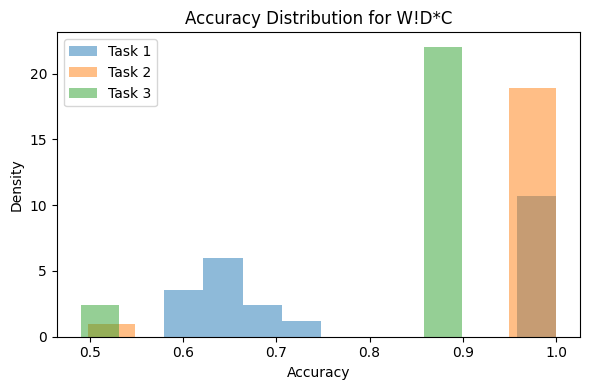

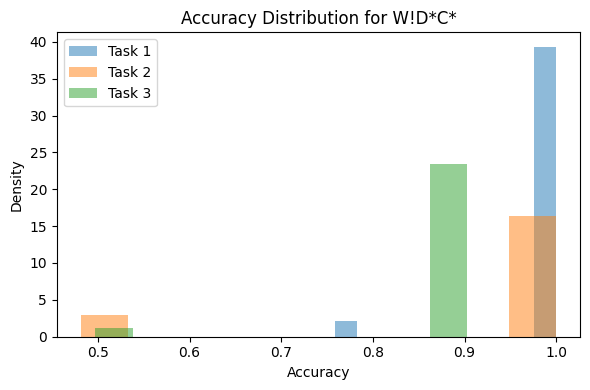

In [ ]:
naive_disturbution_comparision_across_tasks(df1, df2, df3, models, 'Accuracy')

## Sign Constraint

In [ ]:
for model in models:

  mean_acc1, ci95_1 = calculate_confidence_interval(df1[model])
  mean_acc2, ci95_2 = calculate_confidence_interval(df2[model])
  mean_acc3, ci95_3 = calculate_confidence_interval(df3[model])

  print(f"----------Model: {model}-----------")
  print(f"Mean accuracy Task 1: {mean_acc1:.3f}")
  print(f"95% CI Task 1: ({ci95_1[0]:.3f}, {ci95_1[1]:.3f})\n")
  print(f"Mean accuracy Task 2: {mean_acc2:.3f}")
  print(f"95% CI Task 2: ({ci95_2[0]:.3f}, {ci95_2[1]:.3f})\n")
  print(f"Mean accuracy Task 3: {mean_acc3:.3f}")
  print(f"95% CI Task 3: ({ci95_3[0]:.3f}, {ci95_3[1]:.3f})\n")


----------Model: W*D*C-----------
Mean accuracy Task 1: 0.910
95% CI Task 1: (0.840, 0.980)

Mean accuracy Task 2: 0.950
95% CI Task 2: (0.878, 1.022)

Mean accuracy Task 3: 0.834
95% CI Task 3: (0.765, 0.903)

----------Model: WD*C-----------
Mean accuracy Task 1: 0.238
95% CI Task 1: (nan, nan)

Mean accuracy Task 2: 0.499
95% CI Task 2: (nan, nan)

Mean accuracy Task 3: 0.498
95% CI Task 3: (0.498, 0.498)

----------Model: WDC-----------
Mean accuracy Task 1: 0.238
95% CI Task 1: (nan, nan)

Mean accuracy Task 2: 0.499
95% CI Task 2: (nan, nan)

Mean accuracy Task 3: 0.498
95% CI Task 3: (0.498, 0.498)

----------Model: WD*-----------
Mean accuracy Task 1: 0.238
95% CI Task 1: (nan, nan)

Mean accuracy Task 2: 0.499
95% CI Task 2: (nan, nan)

Mean accuracy Task 3: 0.498
95% CI Task 3: (0.498, 0.498)

----------Model: WD-----------
Mean accuracy Task 1: 0.238
95% CI Task 1: (nan, nan)

Mean accuracy Task 2: 0.499
95% CI Task 2: (nan, nan)

Mean accuracy Task 3: 0.498
95% CI Task 3: (

/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [ ]:
for model in models:

  mean_acc1, ci95_1 = calculate_confidence_interval(df1[model])
  mean_acc2, ci95_2 = calculate_confidence_interval(df2[model])
  mean_acc3, ci95_3 = calculate_confidence_interval(df3[model])

  print(f"----------Model: {model}-----------")
  print(f"Mean assortivity Task 1: {mean_acc1:.3f}")
  print(f"95% CI Task 1: ({ci95_1[0]:.3f}, {ci95_1[1]:.3f})\n")
  print(f"Mean assortivity Task 2: {mean_acc2:.3f}")
  print(f"95% CI Task 2: ({ci95_2[0]:.3f}, {ci95_2[1]:.3f})\n")
  print(f"Mean assortivity Task 3: {mean_acc3:.3f}")
  print(f"95% CI Task 3: ({ci95_3[0]:.3f}, {ci95_3[1]:.3f})\n")


----------Model: W*D*C-----------
Mean assortivity Task 1: -0.084
95% CI Task 1: (-0.163, -0.006)

Mean assortivity Task 2: -0.085
95% CI Task 2: (-0.149, -0.022)

Mean assortivity Task 3: -0.183
95% CI Task 3: (-0.226, -0.140)

----------Model: WD*C-----------
Mean assortivity Task 1: nan
95% CI Task 1: (nan, nan)

Mean assortivity Task 2: nan
95% CI Task 2: (nan, nan)

Mean assortivity Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: WDC-----------
Mean assortivity Task 1: nan
95% CI Task 1: (nan, nan)

Mean assortivity Task 2: nan
95% CI Task 2: (nan, nan)

Mean assortivity Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: WD*-----------
Mean assortivity Task 1: nan
95% CI Task 1: (nan, nan)

Mean assortivity Task 2: nan
95% CI Task 2: (nan, nan)

Mean assortivity Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: WD-----------
Mean assortivity Task 1: nan
95% CI Task 1: (nan, nan)

Mean assortivity Task 2: nan
95% CI Task 2: (nan, nan)

Mean assortivity Task 3: na

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-2292540278.py:5: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sem = stats.sem(acc_task)  # standard error of the mean


In [ ]:
for model in models:

  mean_acc1, ci95_1 = calculate_confidence_interval(df1[model])
  mean_acc2, ci95_2 = calculate_confidence_interval(df2[model])
  mean_acc3, ci95_3 = calculate_confidence_interval(df3[model])

  print(f"----------Model: {model}-----------")
  print(f"Mean Entropy Task 1: {mean_acc1:.3f}")
  print(f"95% CI Task 1: ({ci95_1[0]:.3f}, {ci95_1[1]:.3f})\n")
  print(f"Mean Entropy Task 2: {mean_acc2:.3f}")
  print(f"95% CI Task 2: ({ci95_2[0]:.3f}, {ci95_2[1]:.3f})\n")
  print(f"Mean Entropy Task 3: {mean_acc3:.3f}")
  print(f"95% CI Task 3: ({ci95_3[0]:.3f}, {ci95_3[1]:.3f})\n")

----------Model: W*D*C-----------
Mean Entropy Task 1: 0.228
95% CI Task 1: (0.200, 0.256)

Mean Entropy Task 2: 0.147
95% CI Task 2: (0.109, 0.185)

Mean Entropy Task 3: 0.134
95% CI Task 3: (0.103, 0.165)

----------Model: WD*C-----------
Mean Entropy Task 1: nan
95% CI Task 1: (nan, nan)

Mean Entropy Task 2: nan
95% CI Task 2: (nan, nan)

Mean Entropy Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: WDC-----------
Mean Entropy Task 1: nan
95% CI Task 1: (nan, nan)

Mean Entropy Task 2: nan
95% CI Task 2: (nan, nan)

Mean Entropy Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: WD*-----------
Mean Entropy Task 1: nan
95% CI Task 1: (nan, nan)

Mean Entropy Task 2: nan
95% CI Task 2: (nan, nan)

Mean Entropy Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: WD-----------
Mean Entropy Task 1: nan
95% CI Task 1: (nan, nan)

Mean Entropy Task 2: nan
95% CI Task 2: (nan, nan)

Mean Entropy Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: W-----------
Mean Entro

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-2292540278.py:5: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sem = stats.sem(acc_task)  # standard error of the mean


In [ ]:

for model in models:

  mean_acc1, ci95_1 = calculate_confidence_interval(df1[model])
  mean_acc2, ci95_2 = calculate_confidence_interval(df2[model])
  mean_acc3, ci95_3 = calculate_confidence_interval(df3[model])

  print(f"----------Model: {model}-----------")
  print(f"Mean SmallWorldness Task 1: {mean_acc1:.3f}")
  print(f"95% CI Task 1: ({ci95_1[0]:.3f}, {ci95_1[1]:.3f})\n")
  print(f"Mean SmallWorldness Task 2: {mean_acc2:.3f}")
  print(f"95% CI Task 2: ({ci95_2[0]:.3f}, {ci95_2[1]:.3f})\n")
  print(f"Mean SmallWorldness Task 3: {mean_acc3:.3f}")
  print(f"95% CI Task 3: ({ci95_3[0]:.3f}, {ci95_3[1]:.3f})\n")

----------Model: W*D*C-----------
Mean SmallWorldness Task 1: 2.676
95% CI Task 1: (2.426, 2.926)

Mean SmallWorldness Task 2: 2.637
95% CI Task 2: (2.224, 3.050)

Mean SmallWorldness Task 3: 2.013
95% CI Task 3: (1.633, 2.392)

----------Model: WD*C-----------
Mean SmallWorldness Task 1: nan
95% CI Task 1: (nan, nan)

Mean SmallWorldness Task 2: nan
95% CI Task 2: (nan, nan)

Mean SmallWorldness Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: WDC-----------
Mean SmallWorldness Task 1: nan
95% CI Task 1: (nan, nan)

Mean SmallWorldness Task 2: nan
95% CI Task 2: (nan, nan)

Mean SmallWorldness Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: WD*-----------
Mean SmallWorldness Task 1: nan
95% CI Task 1: (nan, nan)

Mean SmallWorldness Task 2: nan
95% CI Task 2: (nan, nan)

Mean SmallWorldness Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: WD-----------
Mean SmallWorldness Task 1: nan
95% CI Task 1: (nan, nan)

Mean SmallWorldness Task 2: nan
95% CI Task 2: (nan, 

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-2292540278.py:5: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sem = stats.sem(acc_task)  # standard error of the mean


In [ ]:

for model in models:

  mean_acc1, ci95_1 = calculate_confidence_interval(df1[model])
  mean_acc2, ci95_2 = calculate_confidence_interval(df2[model])
  mean_acc3, ci95_3 = calculate_confidence_interval(df3[model])

  print(f"----------Model: {model}-----------")
  print(f"Mean Modularity Task 1: {mean_acc1:.3f}")
  print(f"95% CI Task 1: ({ci95_1[0]:.3f}, {ci95_1[1]:.3f})\n")
  print(f"Mean Modularity Task 2: {mean_acc2:.3f}")
  print(f"95% CI Task 2: ({ci95_2[0]:.3f}, {ci95_2[1]:.3f})\n")
  print(f"Mean Modularity Task 3: {mean_acc3:.3f}")
  print(f"95% CI Task 3: ({ci95_3[0]:.3f}, {ci95_3[1]:.3f})\n")

----------Model: W*D*C-----------
Mean Modularity Task 1: 0.412
95% CI Task 1: (0.356, 0.468)

Mean Modularity Task 2: 0.450
95% CI Task 2: (0.415, 0.486)

Mean Modularity Task 3: 0.364
95% CI Task 3: (0.314, 0.413)

----------Model: WD*C-----------
Mean Modularity Task 1: nan
95% CI Task 1: (nan, nan)

Mean Modularity Task 2: nan
95% CI Task 2: (nan, nan)

Mean Modularity Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: WDC-----------
Mean Modularity Task 1: nan
95% CI Task 1: (nan, nan)

Mean Modularity Task 2: nan
95% CI Task 2: (nan, nan)

Mean Modularity Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: WD*-----------
Mean Modularity Task 1: nan
95% CI Task 1: (nan, nan)

Mean Modularity Task 2: nan
95% CI Task 2: (nan, nan)

Mean Modularity Task 3: nan
95% CI Task 3: (nan, nan)

----------Model: WD-----------
Mean Modularity Task 1: nan
95% CI Task 1: (nan, nan)

Mean Modularity Task 2: nan
95% CI Task 2: (nan, nan)

Mean Modularity Task 3: nan
95% CI Task 3: (nan, n

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-2292540278.py:5: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sem = stats.sem(acc_task)  # standard error of the mean


## STTC-Corr

In [ ]:
session, scan, field = 6, 6, 2

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

metric = 'Modularity' # choose the metric: Accuracy, Assortativity, Entropy, Loss, Modularity, SmallWorldness, Validation_Accuracy, Validation_Loss

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name = f'/content/data/simu/{base}'


task1_file_dir = f'{folder_name}/Task1/{metric}_raw.csv'
task2_file_dir = f'{folder_name}/Task2/{metric}_raw.csv'
task3_file_dir = f'{folder_name}/Task3/{metric}_raw.csv'

In [ ]:
metrics=['Accuracy', 'Assortativity', 'Entropy', 'Modularity', 'SmallWorldness']

In [ ]:
for metric in metrics:

  print()
  print(f'----------{metric}----------')
  print()

  task1_file_dir = f'{folder_name}/Task1/{metric}_raw.csv'
  task2_file_dir = f'{folder_name}/Task2/{metric}_raw.csv'
  task3_file_dir = f'{folder_name}/Task3/{metric}_raw.csv'
  df1 = pd.read_csv(task1_file_dir)
  df2 = pd.read_csv(task2_file_dir)
  df3 = pd.read_csv(task3_file_dir)

  df1.drop('simulation', axis=1, inplace=True)
  df2.drop('simulation', axis=1, inplace=True)
  df3.drop('simulation', axis=1, inplace=True)

  models = df1.columns
  for model in models:

    mean_acc1, ci95_1 = calculate_confidence_interval(df1[model])
    mean_acc2, ci95_2 = calculate_confidence_interval(df2[model])
    mean_acc3, ci95_3 = calculate_confidence_interval(df3[model])

    print(f"----------Model: {model}-----------")
    print(f"Mean {metric} Task 1: {mean_acc1:.3f}")
    print(f"95% CI Task 1: ({ci95_1[0]:.3f}, {ci95_1[1]:.3f})\n")
    print(f"Mean {metric} Task 2: {mean_acc2:.3f}")
    print(f"95% CI Task 2: ({ci95_2[0]:.3f}, {ci95_2[1]:.3f})\n")
    print(f"Mean {metric} Task 3: {mean_acc3:.3f}")
    print(f"95% CI Task 3: ({ci95_3[0]:.3f}, {ci95_3[1]:.3f})\n")



----------Accuracy----------

----------Model: W*D*C-----------
Mean Accuracy Task 1: 0.917
95% CI Task 1: (0.853, 0.981)

Mean Accuracy Task 2: 0.948
95% CI Task 2: (0.878, 1.018)

Mean Accuracy Task 3: 0.865
95% CI Task 3: (0.824, 0.906)

----------Model: WD*C-----------
Mean Accuracy Task 1: 0.628
95% CI Task 1: (0.626, 0.631)

Mean Accuracy Task 2: 0.939
95% CI Task 2: (0.869, 1.009)

Mean Accuracy Task 3: 0.812
95% CI Task 3: (0.747, 0.876)

----------Model: WDC-----------
Mean Accuracy Task 1: 0.624
95% CI Task 1: (0.622, 0.626)

Mean Accuracy Task 2: 0.511
95% CI Task 2: (0.510, 0.511)

Mean Accuracy Task 3: 0.500
95% CI Task 3: (0.500, 0.501)

----------Model: WD*-----------
Mean Accuracy Task 1: 0.787
95% CI Task 1: (0.700, 0.874)

Mean Accuracy Task 2: 0.512
95% CI Task 2: (0.511, 0.512)

Mean Accuracy Task 3: 0.500
95% CI Task 3: (0.499, 0.501)

----------Model: WD-----------
Mean Accuracy Task 1: 0.628
95% CI Task 1: (0.625, 0.630)

Mean Accuracy Task 2: 0.511
95% CI Task 

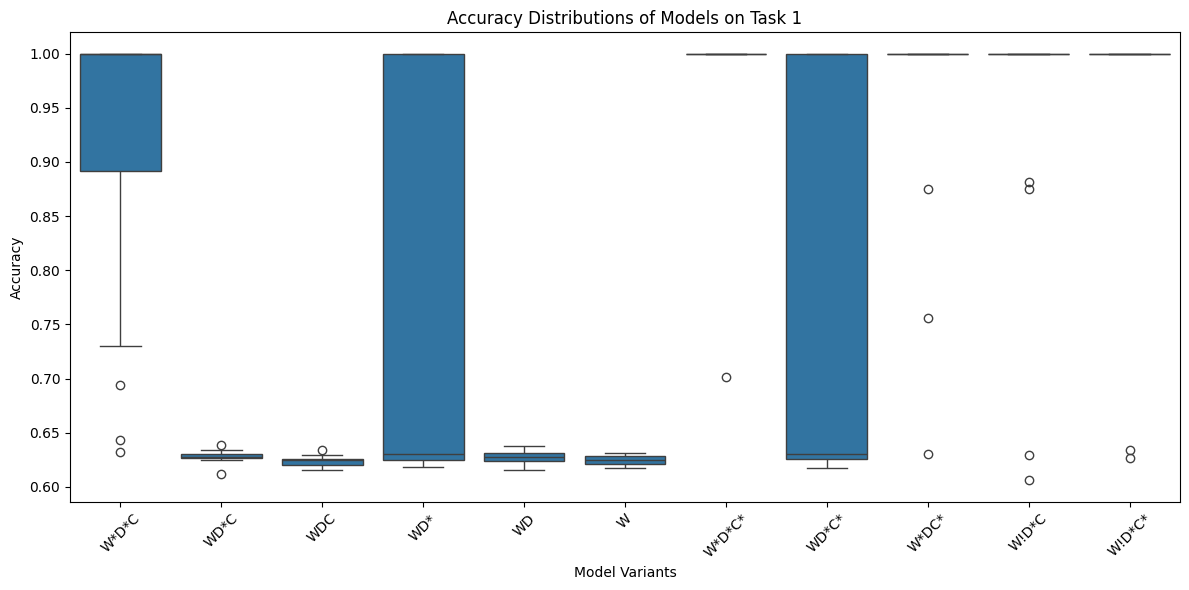

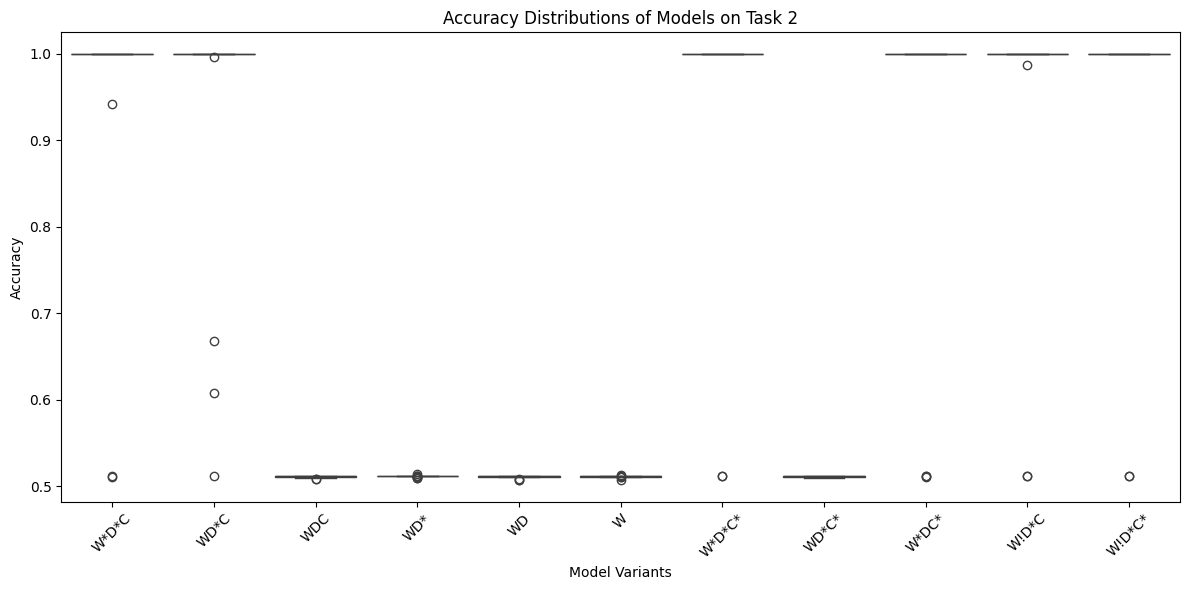

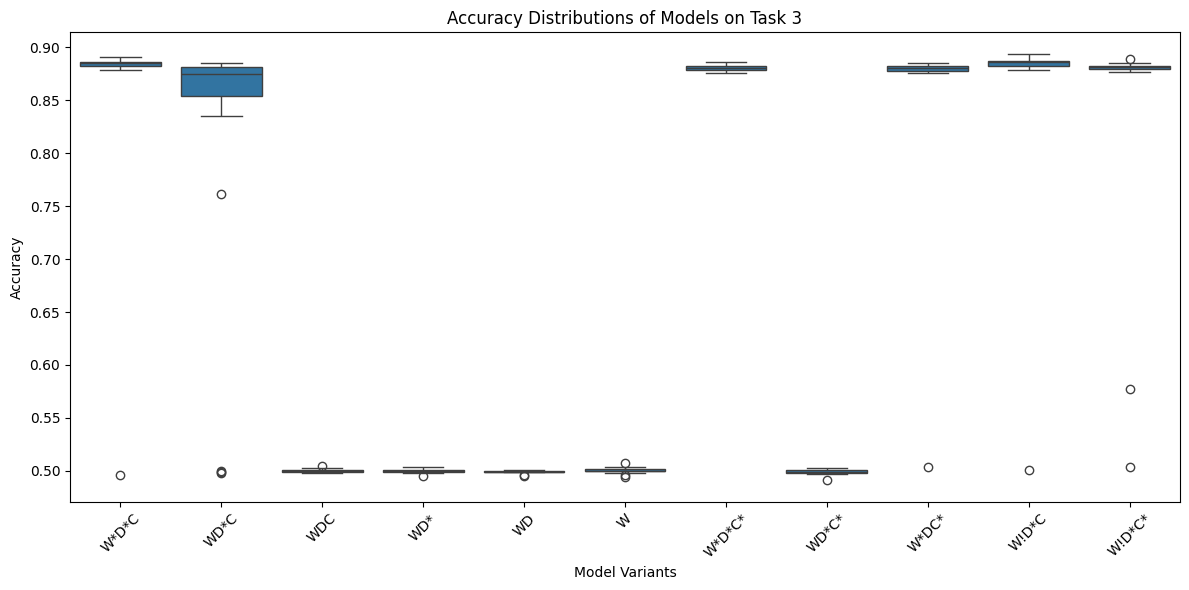

In [ ]:
task_box_plots([df1, df2, df3], "Accuracy")

/tmp/ipython-input-498221133.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


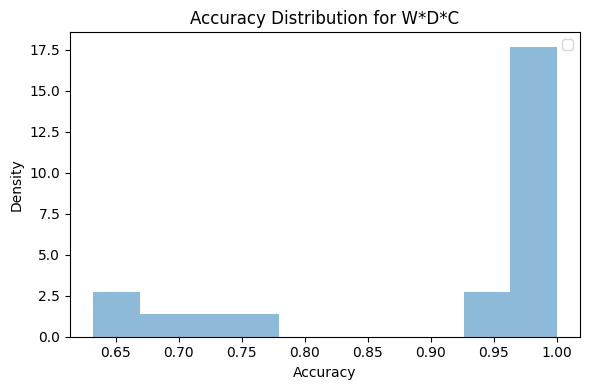

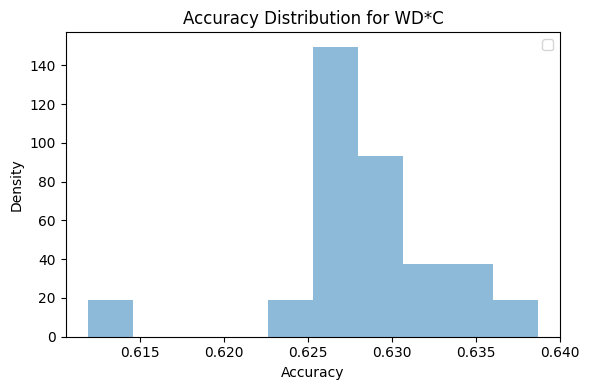

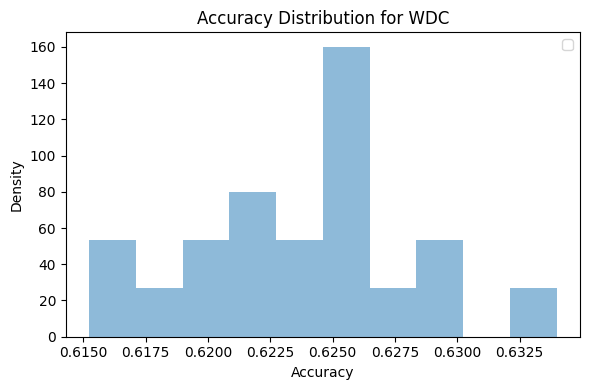

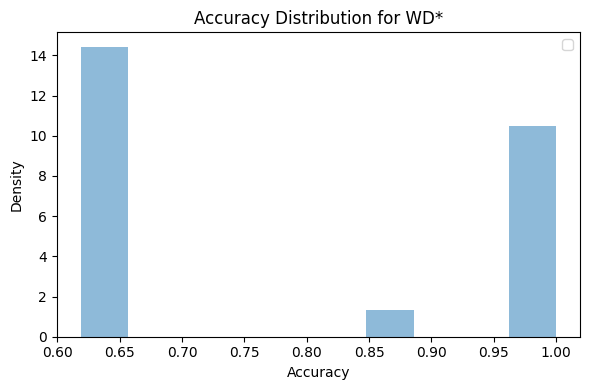

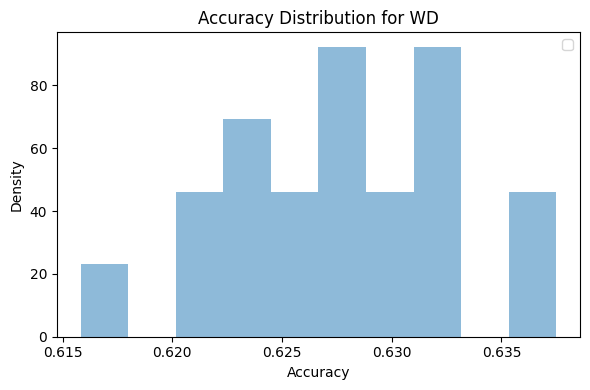

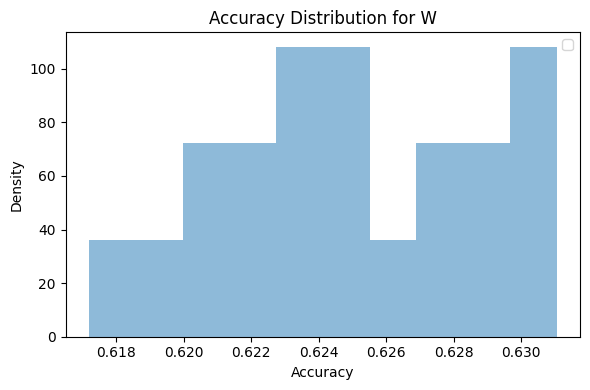

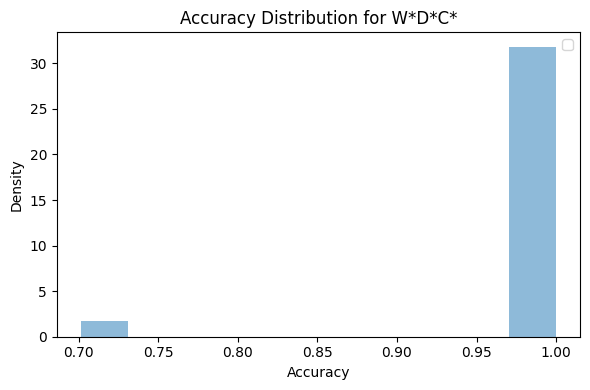

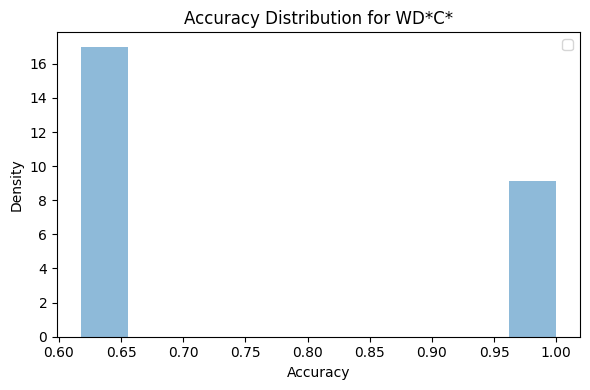

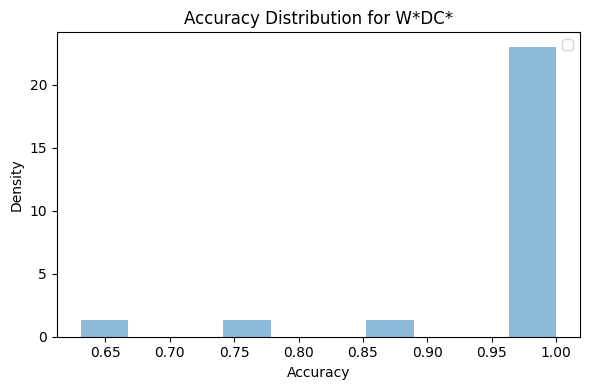

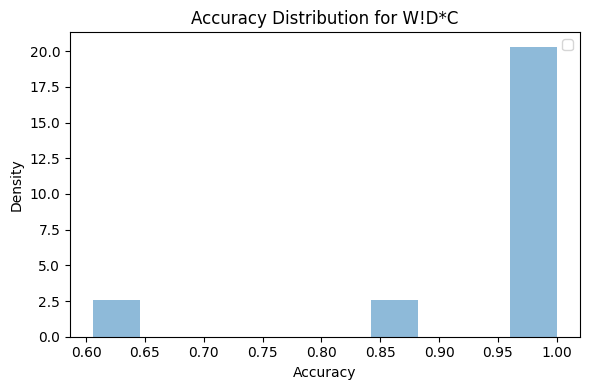

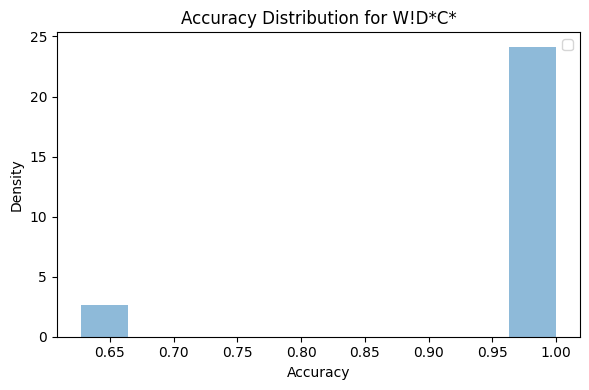

In [ ]:
draw_model_disturbutions(df1, models, 'Accuracy')

In [ ]:
stat1, p1 = kruskal(df1['W!D*C'], df1['W!D*C*'], df1['W'], df1['W*D*C'], df1['W*D*C*'], df1['W*DC*'], df1['WD'], df1['WD*'], df1['WD*C'], df1['WD*C*'], df1['WDC'])
print(f'Task 1: {stat1}, {p1}')

stat2, p2 = kruskal(df2['W!D*C'], df2['W!D*C*'], df2['W'], df2['W*D*C'], df2['W*D*C*'], df2['W*DC*'], df2['WD'], df2['WD*'], df2['WD*C'], df2['WD*C*'], df2['WDC'])
print(f'Task 2: {stat2}, {p2}')

stat3, p3 = kruskal(df3['W!D*C'], df3['W!D*C*'], df3['W'], df3['W*D*C'], df3['W*D*C*'], df3['W*DC*'], df3['WD'], df3['WD*'], df3['WD*C'], df3['WD*C*'], df3['WDC'])
print(f'Task 3: {stat3}, {p3}')

Task 1: 140.06017037320012, 4.0964206182678477e-25
Task 2: 157.78387547157624, 9.287146935613016e-29
Task 3: 160.81168445865617, 2.2029113281232366e-29


In [ ]:
same_model_accuracies_1 = check_disturbution_difference(df1, models)
same_model_accuracies_2 = check_disturbution_difference(df2, models)
same_model_accuracies_3 = check_disturbution_difference(df3, models)

Model W*D*C vs Model WD*C
stat = 397.0, p = 6.35602883335682e-08
Model W*D*C vs Model WDC
stat = 399.0, p = 4.653571872945986e-08
Model W*D*C vs Model WD*
stat = 287.0, p = 0.011412071631301817
Model W*D*C vs Model WD
stat = 396.0, p = 7.387463840333483e-08
Model W*D*C vs Model W
stat = 400.0, p = 3.995358749418445e-08
Model W*D*C vs Model W*D*C*
stat = 140.5, p = 0.022360848043512155
Model W*D*C vs Model WD*C*
stat = 303.5, p = 0.002900126065174305
Model W*D*C vs Model W*DC*
stat = 161.5, p = 0.17648719883956754
Model W*D*C vs Model W!D*C
stat = 174.0, p = 0.380688532776273
Model W*D*C vs Model W!D*C*
stat = 156.0, p = 0.1075814397269352
Model WD*C vs Model WDC
stat = 323.5, p = 0.0008749023080461889
Model WD*C vs Model WD*
stat = 157.0, p = 0.24831238566240876
Model WD*C vs Model WD
stat = 225.0, p = 0.5073259929987154
Model WD*C vs Model W
stat = 296.0, p = 0.009772742038963398
Model WD*C vs Model W*D*C*
stat = 0.0, p = 1.1266570353724972e-08
Model WD*C vs Model WD*C*
stat = 161.5, 